# **News Category**

---

News headline categorization with fine-tuned DistilBERT, BiLSTM, logistic regression, and Naive Bayes.

## **Naive Bayes**

---

Trains a Multinomial Naive Bayes classifier on TF-IDF features across the five field configurations, tuning `alpha` over the shared folds and scoring each on the held-out test split. This is the simplest model, run first to validate the shared training and evaluation pipeline.

Outputs (under `data/models/naive_bayes/`):

- `scores.json`: test metrics per field configuration

### **Setup**

---

#### **Config**


In [1]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

from news_category.data import load_split, assemble_fields, CONFIGS
from news_category.display import show
from news_category.evaluate import tune_hyperparameter
from news_category.plotting import plot_confusion_matrix, plot_per_class_f1, plot_learning_curve, plot_metric_comparison

VERSION = "v1"
DIR_OUT = Path("results/naive_bayes")

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.titleweight"] = "bold"
plt.rcParams["figure.titlesize"] = 18

#### **Load**


In [2]:
(df_train, df_test), labels = load_split(VERSION)
y_train = df_train["category"]
y_test = df_test["category"]
show("Split Shapes", pd.DataFrame([df_train.shape, df_test.shape], index=["train", "test"], columns=["rows", "columns"]))

── Split Shapes ────────────────────────────


,rows,columns
train,167218,6
test,41805,6


### **Training**

---

For each field configuration, assemble the input text and tune the pipeline over the shared folds, scoring on the test split. The author-only configuration drops blank-author rows so it measures author signal fairly; the other configurations keep every row.


#### **Recipe**

A pipeline of TF-IDF features and Naive Bayes, tuned together over the shared folds. The grid spans the vectorizer (n-gram range, term-frequency scaling, minimum document frequency, stopwords) and the classifier (smoothing, class prior, and the Multinomial or Complement variant).


In [3]:
CLF = Pipeline([("tfidf", TfidfVectorizer()), ("nb", MultinomialNB())])
GRID = {
  "tfidf__ngram_range": [(1, 1), (1, 2)],
  "tfidf__sublinear_tf": [True, False],
  "tfidf__min_df": [1, 5],
  "tfidf__stop_words": [None, "english"],
  "nb": [MultinomialNB(), ComplementNB(norm=False), ComplementNB(norm=True)],
  "nb__alpha": [0.1, 0.5, 1.0],
  "nb__fit_prior": [True, False],
}

#### **Per-Field Grid Search**

Tune the pipeline for each field configuration and score the best on the test split; the author-only configurations use just the author-present rows.


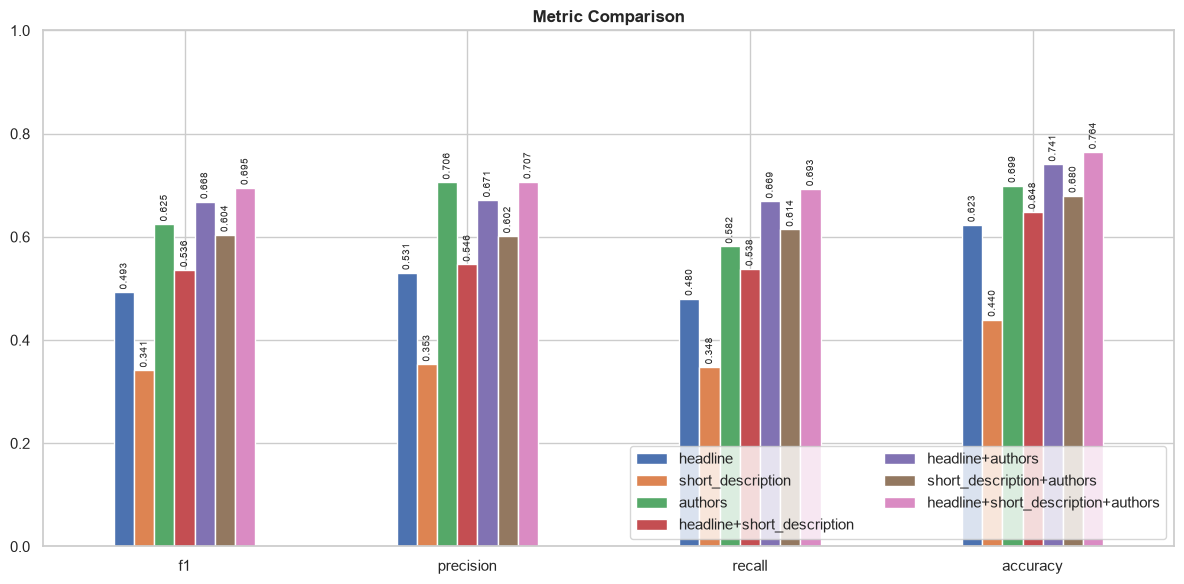

In [4]:
results = {}
predictions = {}
estimators = {}
inputs = {}
best_params = {}

for config in CONFIGS:
  train_mask = df_train["has_author"] if config == "authors" else pd.Series(True, index=df_train.index)
  test_mask = df_test["has_author"] if config == "authors" else pd.Series(True, index=df_test.index)

  X_train = assemble_fields(df_train[train_mask], config)
  X_test = assemble_fields(df_test[test_mask], config)

  result = tune_hyperparameter(CLF, GRID, X_train, y_train[train_mask], X_test, y_test[test_mask])
  results[config] = result.scores
  predictions[config] = result.predictions
  estimators[config] = result.estimator
  inputs[config] = (X_train, y_train[train_mask], y_test[test_mask])
  best_params[config] = {k: repr(v) if k == "nb" else v for k, v in result.best_params.items()}
  clear_output(wait=True)

fig, ax = plt.subplots(figsize=(12, 6))
plot_metric_comparison(results, ax=ax)
plt.tight_layout()
plt.show()

### **Diagnostics**

---

#### **Field Strengths & Weaknesses**

Three plots reveal what each configuration does well and poorly:

- Confusion matrix: which categories get mistaken for each other.

- Per-class F1: which categories the model handles worst.

- Learning curve: whether the model overfits or would benefit from more data.


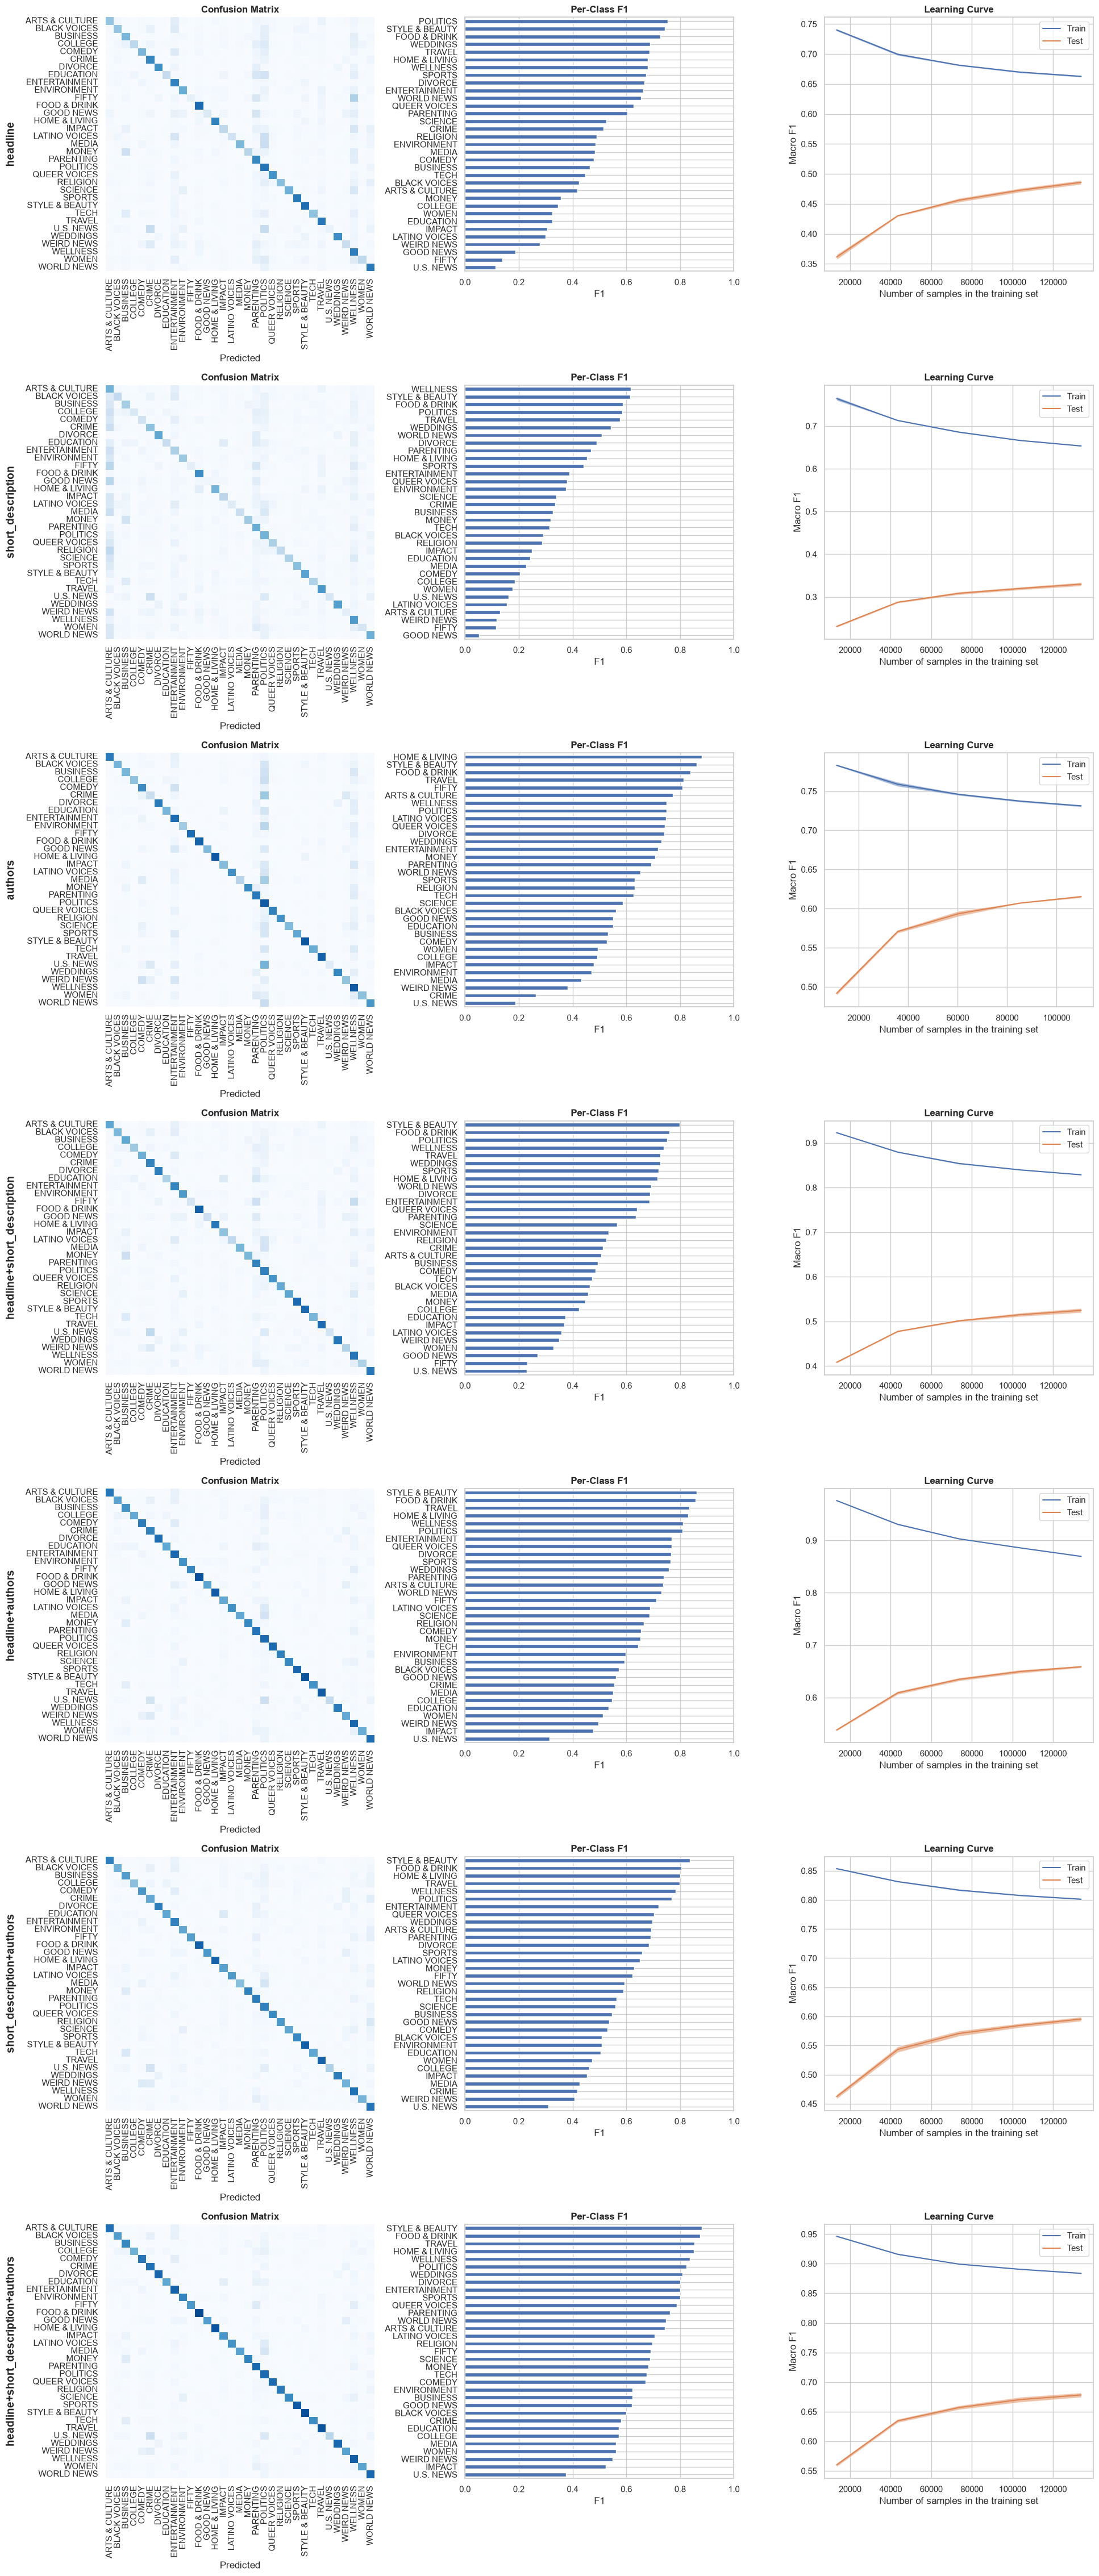

In [5]:
fig, axes = plt.subplots(len(CONFIGS), 3, figsize=(3 * 6.5, len(CONFIGS) * 6.5))
for row, config in zip(axes, CONFIGS):
  X_train, y_tr, y_te = inputs[config]
  plot_confusion_matrix(y_te, predictions[config], labels, ax=row[0])
  plot_per_class_f1(y_te, predictions[config], labels, ax=row[1])
  plot_learning_curve(estimators[config], X_train, y_tr, ax=row[2])
  row[0].set_ylabel(config, fontsize=14, fontweight="bold", labelpad=12)
plt.tight_layout()
plt.show()

#### **Best Hyperparameters**

The winning grid combination behind each configuration's score.


In [6]:
show("Best Hyperparameters", pd.DataFrame(best_params).T)

── Best Hyperparameters ────────────────────


,nb,nb__alpha,nb__fit_prior,tfidf__min_df,tfidf__ngram_range,tfidf__stop_words,tfidf__sublinear_tf
headline,MultinomialNB(),0.5,False,5,"(1, 2)",english,True
short_description,MultinomialNB(),0.1,False,5,"(1, 2)",english,False
authors,MultinomialNB(),0.1,True,1,"(1, 2)",None,True
headline+short_description,MultinomialNB(),0.1,False,5,"(1, 2)",english,False
headline+authors,MultinomialNB(),0.1,False,1,"(1, 1)",english,False
short_description+authors,MultinomialNB(),0.1,False,5,"(1, 2)",english,False
headline+short_description+authors,MultinomialNB(),0.1,False,5,"(1, 2)",english,True


### **Output**

---

Write the per-configuration test scores and winning hyperparameters, for the comparison notebook.


In [7]:
DIR_OUT = Path("results/naive_bayes")
DIR_OUT.mkdir(parents=True, exist_ok=True)
with open(DIR_OUT / "scores.json", "w") as f:
  json.dump(results, f, indent=2)
with open(DIR_OUT / "best_params.json", "w") as f:
  json.dump(best_params, f, indent=2)
show("Saved", str(DIR_OUT))

── Saved ───────────────────────────────────
results/naive_bayes
